<a href="https://colab.research.google.com/github/Sayandt-web/IRIS-FLOWER/blob/main/IRIS_FLOWER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import zipfile

# Unzip iris.zip to get iris.data
with zipfile.ZipFile('iris.zip', 'r') as zip_ref:
    zip_ref.extractall('.') # Extract to current directory

iris = pd.read_csv("iris.data", header=None)
iris.columns = ["sepal_length","sepal_width","petal_length","petal_width","class"]
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X = iris.iloc[:,:-1]
Y = iris.iloc[:, -1]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, Y_train)

GaussianNB()

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
Y_pred = gnb.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model accuracy: {accuracy:.2f}")

Model accuracy: 1.00


# Task
Generate a bar chart to visualize the accuracy score of the trained Gaussian Naive Bayes model.

## Plot Model Accuracy

### Subtask:
Generate a bar chart to visualize the accuracy score of the trained Gaussian Naive Bayes model. The plot will clearly display the accuracy value.


**Reasoning**:
To visualize the model accuracy, I will generate a bar chart using `matplotlib.pyplot` as instructed, setting the title, labels, and text annotations appropriately.



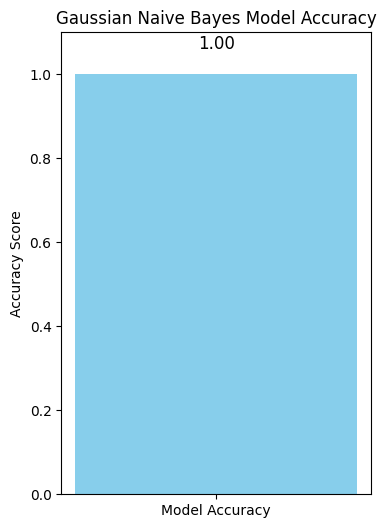

Generated bar chart for model accuracy.


In [ ]:
import matplotlib.pyplot as plt

# Create a bar chart for model accuracy
plt.figure(figsize=(4, 6))
plt.bar(['Model Accuracy'], [accuracy], color='skyblue')

# Add title and labels
plt.title('Gaussian Naive Bayes Model Accuracy')
plt.ylabel('Accuracy Score')

# Add the accuracy value as text on top of the bar
plt.text(0, accuracy + 0.05, f'{accuracy:.2f}', ha='center', va='bottom', fontsize=12)

# Set y-axis limits for better visualization
plt.ylim(0, 1.1)

# Display the plot
plt.show()
print("Generated bar chart for model accuracy.")

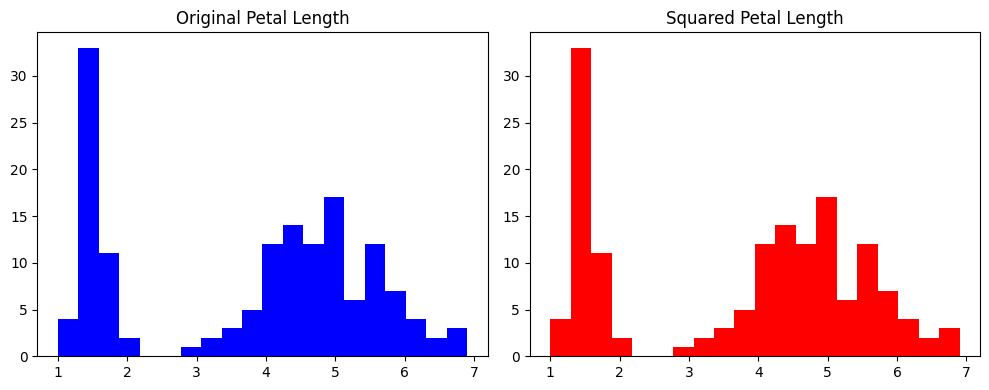

GaussianNB Accuracy: 0.9111111111111111
Logistic Regression Accuracy: 0.9333333333333333

GaussianNB Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Logistic Regression Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


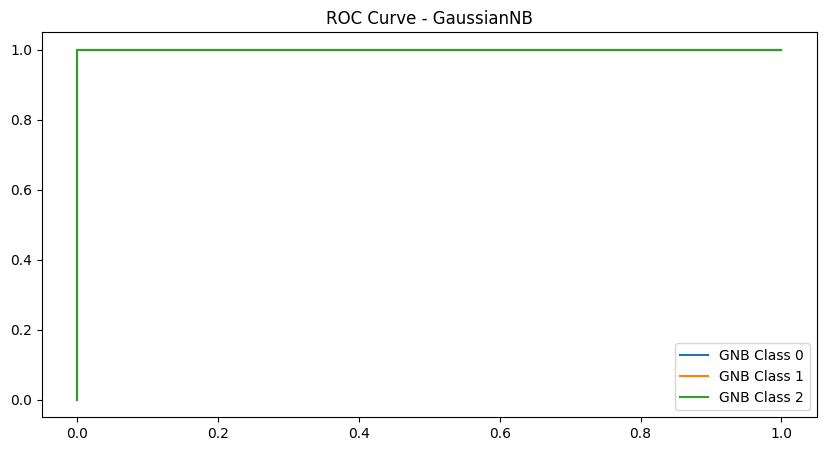

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# 1️⃣ Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Keep original copy for histogram
X_original = X.copy()

# 2️⃣ Apply transformation (square petal length: column index 2)
X[:, 2] ** 2 == X[:, 2] ** 2

# 3️⃣ Plot histogram before & after transformation
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(X_original[:,2], bins=20, color='blue')
plt.title("Original Petal Length")

plt.subplot(1,2,2)
plt.hist(X[:,2], bins=20, color='red')
plt.title("Squared Petal Length")

plt.tight_layout()
plt.show()

# 4️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5️⃣ Train models
gnb = GaussianNB()
logreg = LogisticRegression(max_iter=300)

gnb.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# 6️⃣ Accuracy comparison
print("GaussianNB Accuracy:", accuracy_score(y_test, gnb.predict(X_test)))
print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg.predict(X_test)))

# 7️⃣ Confusion Matrices
print("\nGaussianNB Confusion Matrix:\n", confusion_matrix(y_test, gnb.predict(X_test)))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, logreg.predict(X_test)))

# 8️⃣ ROC Curves (One-vs-Rest for multiclass)

y_bin = label_binarize(y, classes=[0,1,2])
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_bin, test_size=0.3, random_state=42
)

gnb_ovr = OneVsRestClassifier(GaussianNB()).fit(X_train2, y_train2)
log_ovr = OneVsRestClassifier(LogisticRegression(max_iter=300)).fit(X_train2, y_train2)

plt.figure(figsize=(10,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test2[:, i], gnb_ovr.predict_proba(X_test2)[:, i])
    plt.plot(fpr, tpr, label=f"GNB Class {i}")

plt.title("ROC Curve - GaussianNB")
plt.legend()
plt.show()

Original Shape: (150, 4)
New Shape with Noise: (150, 24)

Training Accuracy
GaussianNB: 0.9904761904761905
Logistic Regression: 1.0

Test Accuracy
GaussianNB: 0.8888888888888888
Logistic Regression: 0.8666666666666667

5-Fold Cross Validation Accuracy
GaussianNB: 0.9473214285714286
Logistic Regression: 0.91875


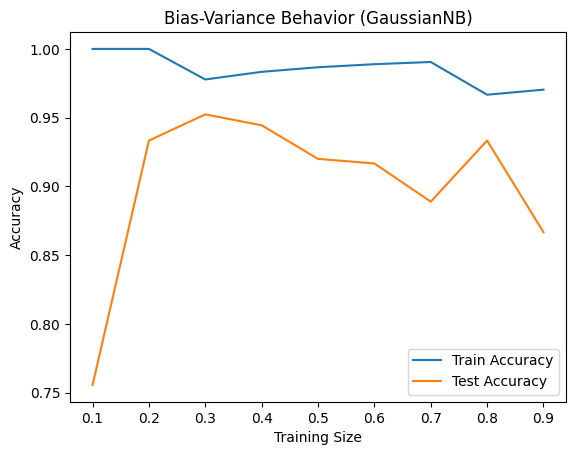

In [ ]:
from sklearn.model_selection import cross_val_score

# Reload clean Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 1️⃣ Add 20 random noise features
np.random.seed(42)
noise = np.random.normal(0, 1, size=(X.shape[0], 20))
X_noisy = np.hstack((X, noise))

print("Original Shape:", X.shape)
print("New Shape with Noise:", X_noisy.shape)

# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y, test_size=0.3, random_state=42, stratify=y
)

# 3️⃣ Train models
gnb = GaussianNB()
logreg = LogisticRegression(max_iter=500)

gnb.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# 4️⃣ Training Accuracy
print("\nTraining Accuracy")
print("GaussianNB:", gnb.score(X_train, y_train))
print("Logistic Regression:", logreg.score(X_train, y_train))

# 5️⃣ Test Accuracy
print("\nTest Accuracy")
print("GaussianNB:", gnb.score(X_test, y_test))
print("Logistic Regression:", logreg.score(X_test, y_test))

# 6️⃣ K-Fold Cross Validation (5-fold)
gnb_cv = cross_val_score(gnb, X_noisy, y, cv=20)
log_cv = cross_val_score(logreg, X_noisy, y, cv=20)

print("\n5-Fold Cross Validation Accuracy")
print("GaussianNB:", gnb_cv.mean())
print("Logistic Regression:", log_cv.mean())

# 7️⃣ Bias-Variance Visualization
train_sizes = np.linspace(0.1, 0.9, 9) # Changed endpoint from 1.0 to 0.9 and reduced num to 9
gnb_train_acc = []
gnb_test_acc = []

for size in train_sizes:
    X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
        X_noisy, y, train_size=size, random_state=42, stratify=y
    )
    gnb.fit(X_train_small, y_train_small)
    gnb_train_acc.append(gnb.score(X_train_small, y_train_small))
    gnb_test_acc.append(gnb.score(X_test_small, y_test_small))

plt.figure()
plt.plot(train_sizes, gnb_train_acc, label="Train Accuracy")
plt.plot(train_sizes, gnb_test_acc, label="Test Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Behavior (GaussianNB)")
plt.legend()
plt.show()